# Visualização de Focus de Modelos

### Notebook para Carregar e Visualizar, Via Mapas de Calor, o Foco dos Modelos nas Imagens

In [1]:
import os
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf


def _resolve_project_root():
    """Sobe diretórios até encontrar utils/models_to_pkl.py."""
    here = Path.cwd().resolve()
    for base in [here, *here.parents]:
        if (base / "utils" / "models_to_pkl.py").is_file():
            return str(base)
    raise FileNotFoundError("Raiz do repositório não encontrada (esperado utils/models_to_pkl.py).")


project_root = _resolve_project_root()
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from utils.gradcam import find_last_spatial_layer_name, make_gradcam_heatmap, overlay_jet_on_rgb
from utils.models_to_pkl import load_model
from utils.tf_gpu import configure_gpu_memory_growth, log_gpu_status

configure_gpu_memory_growth()
log_gpu_status()


I0000 00:00:1778848995.436557   58282 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.



TensorFlow devices
  GPU count: 1
  [0] /physical_device:GPU:0
  CPU count: 1



I0000 00:00:1778849000.761952   58282 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2563 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [2]:
SAMPLE_NPY_DIR = os.path.join(
    project_root,
    "data",
    "CO2Wounds-V2",
    "processed",
    "train_images_binary",
    "train",
    "leprosy",
)


## Modelo treinado do zero em canal Y (`.npy`): entrada `(1, 224, 224, 1)` — **sem** pesos ImageNet


In [3]:
def get_img_array(img_path):
    """Arrays .npy do pipeline estão em [0,1] (float), como no treino."""
    img = np.load(img_path)
    if img.ndim == 2:
        img = img[..., np.newaxis]
    img = tf.image.resize(img.astype(np.float32), (224, 224)).numpy()
    return tf.constant(np.expand_dims(img, axis=0), dtype=tf.float32)


def _npy_to_display_rgb(img_path):
    arr = np.load(img_path)
    if arr.ndim == 3:
        arr = arr[..., 0]
    arr = cv2.resize(arr, (224, 224))
    if arr.max() <= 1.0:
        v = np.clip(arr * 255.0, 0, 255).astype(np.uint8)
    else:
        v = np.clip(arr, 0, 255).astype(np.uint8)
    return np.stack([v, v, v], axis=-1)


def display_gradcam(img_path, heatmap, alpha=0.5, gamma=2.0, percentile=80):
    rgb = _npy_to_display_rgb(img_path)
    overlay = overlay_jet_on_rgb(rgb, heatmap, alpha=alpha, gamma=gamma, percentile=percentile)
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.title("Canal Y (visualização)")
    plt.imshow(rgb)
    plt.axis("off")
    plt.subplot(1, 2, 2)
    plt.title("Grad-CAM")
    plt.imshow(overlay)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


# Treino “from zero” em .npy processados: use o checkpoint correspondente (ou CO2WOUNDS_FROMZERO_MODEL).
_fromzero_base = os.environ.get(
    "CO2WOUNDS_FROMZERO_MODEL", "modelo_binario_co2wounds_fromzero_processed"
)
model_path = os.path.join(project_root, "models", _fromzero_base)
model = load_model(model_path)


✅ Modelo carregado de: /home/alyssandro/Documentos/Github/leprosy_classification_models-TCC/models/modelo_binario_co2wounds_fromzero_processed.keras


Grad-CAM usando camada: conv5_block3_out


/home/alyssandro/Documentos/Github/leprosy_classification_models-TCC/.venv/lib/python3.10/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer']]
Received: inputs=['Tensor(shape=(1, 224, 224, 1))']
  warnings.warn(msg)
I0000 00:00:1778849017.665908   58282 cuda_dnn.cc:461] Loaded cuDNN version 92200


IMG1000.npy


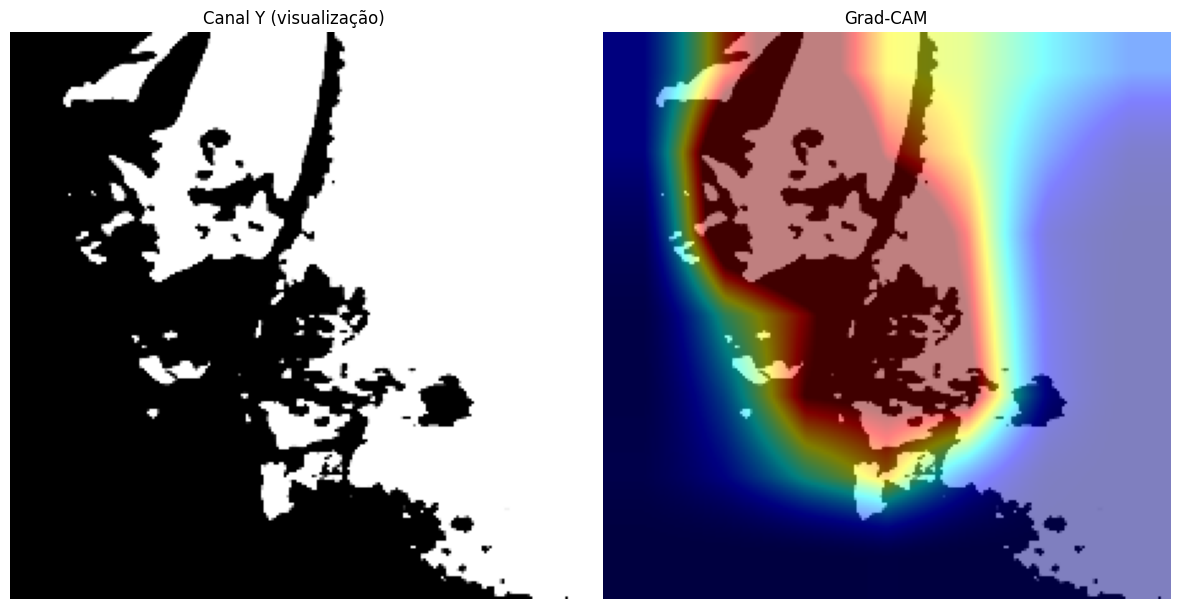

IMG1001.npy


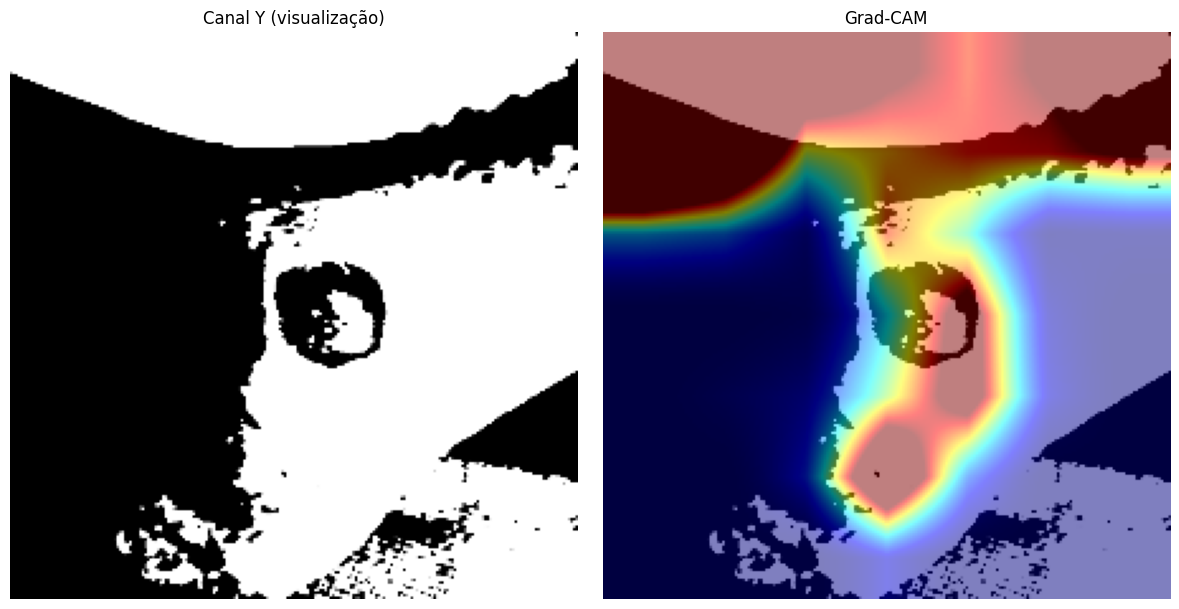

IMG1002.npy


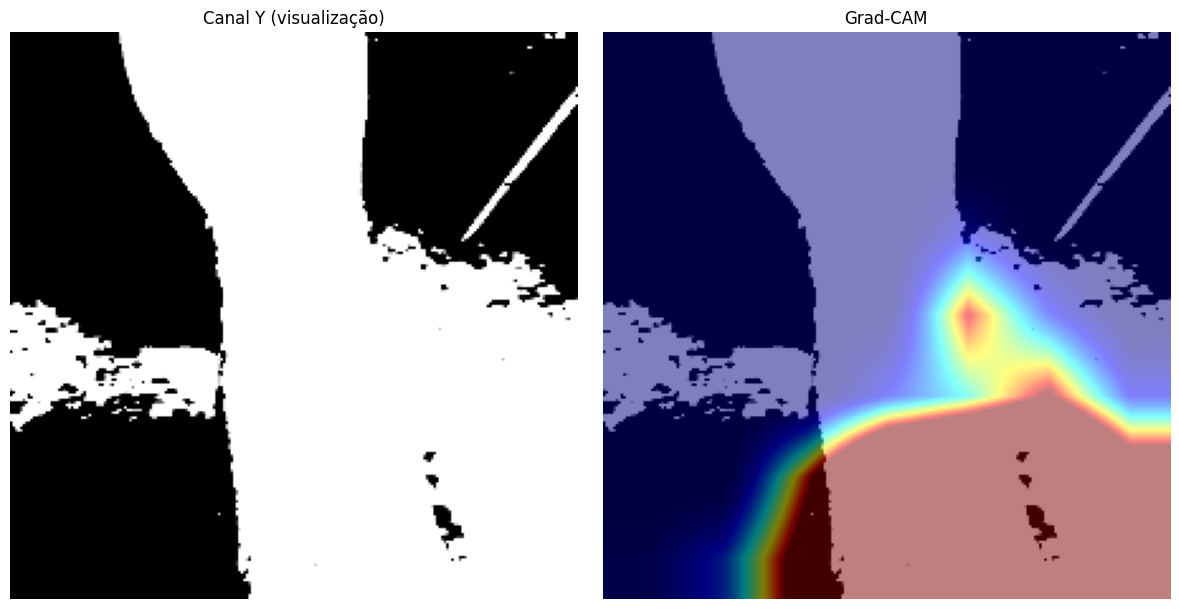

KeyboardInterrupt: 

In [4]:
LAST_CONV = find_last_spatial_layer_name(model)
print("Grad-CAM usando camada:", LAST_CONV)

for img in sorted(os.listdir(SAMPLE_NPY_DIR)):
    if not img.endswith(".npy"):
        continue
    img_path = os.path.join(SAMPLE_NPY_DIR, img)
    img_array = get_img_array(img_path)
    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name=LAST_CONV)
    print(img)
    display_gradcam(img_path, heatmap)


In [ ]:
img_path = os.path.join(SAMPLE_NPY_DIR, "IMG558.npy")
if os.path.isfile(img_path):
    img_array = get_img_array(img_path)
    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name=LAST_CONV)
    display_gradcam(img_path, heatmap)
else:
    print("Arquivo de exemplo não encontrado:", img_path)
